In [1]:
import xgboost as xgb
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

import xesmf as xe

from sklearn.preprocessing import StandardScaler

import sys

sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import sat_preprocess

In [2]:
model = xgb.XGBRegressor()
# model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")
model.load_model("/scratch/er8/cd3022/xgb_models/radiance_model.json")

In [3]:
data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_radiances_2025-01-01+5.parquet')

In [4]:
X = data.drop(columns=['surface_global_irradiance'])
for n in range(1, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])
y = data['surface_global_irradiance_t6']

In [15]:
df = X.join(y)
df['surface_global_irradiance'] = data['surface_global_irradiance']
df['forecast_t6'] = model.predict(X)

In [16]:
ds = df.to_xarray()

Text(0, 0.5, 'XGB Forecast T+60min')

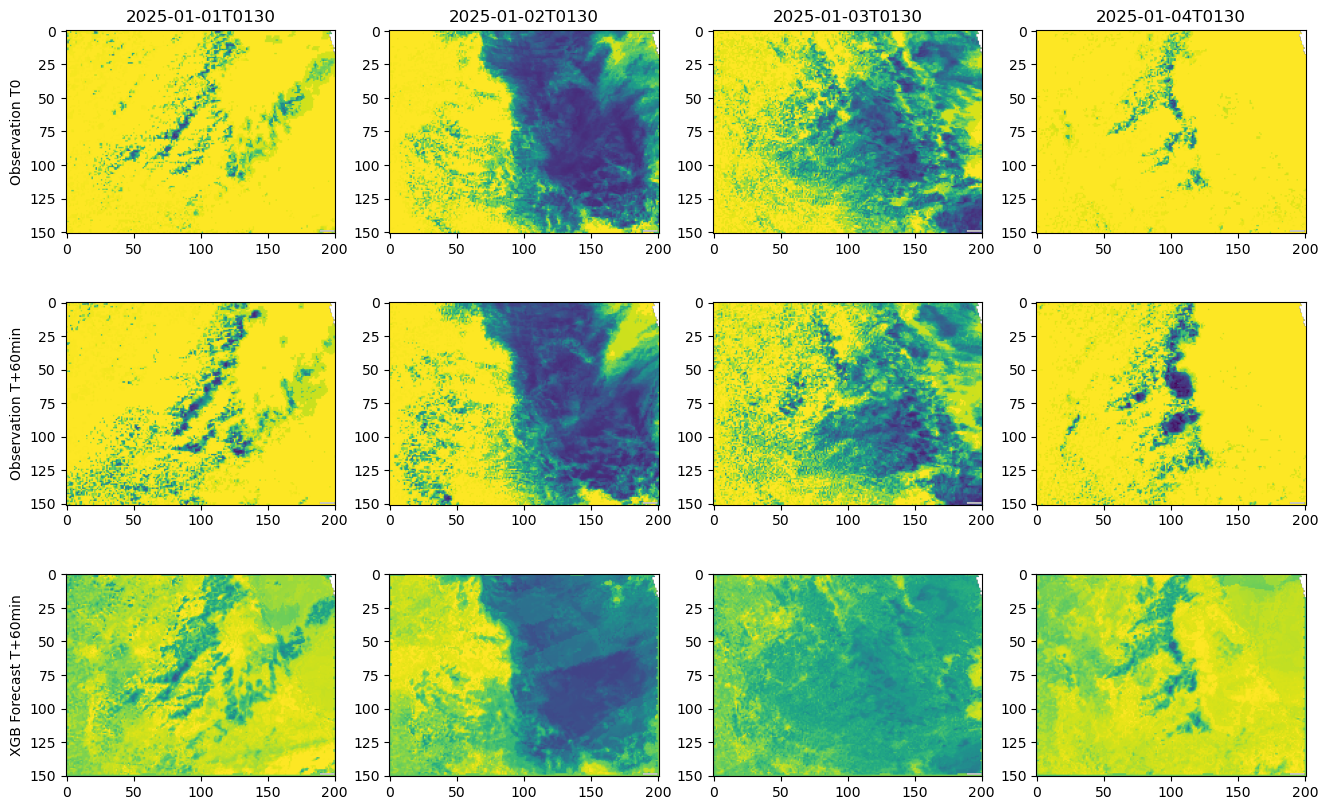

In [18]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(16,10))

times = [
    '01T0130',
    '02T0130',
    '03T0130',
    '04T0130'
]

for i, t in enumerate(times):
    time= f'2025-01-{t}'
    ds_t = ds.sel(time=time)
    ax[0,i].imshow(
        ds_t.surface_global_irradiance,
        vmin=0, vmax=1000
    )
    ax[1,i].imshow(
        ds_t.surface_global_irradiance_t6,
        vmin=0, vmax=1000
    )
    ax[2,i].imshow(
        ds_t.forecast_t6,
        vmin=0, vmax=1000
    )

    ax[0,i].set_title(time)
ax[0,0].set_ylabel('Observation T0')
ax[1,0].set_ylabel('Observation T+60min')
ax[2,0].set_ylabel('XGB Forecast T+60min')

In [19]:
gso_path = Path('/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/01/01')
gso_files = [f for f in gso_path.glob('*.nc')]

# gso = xr.open_mfdataset(gso_files)

In [33]:
gso = xr.open_dataset('/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/01/04/20250104T013000.nc')

In [34]:
gso = gso.sel(
    latitude=ds.latitude,
    longitude=ds.longitude
)

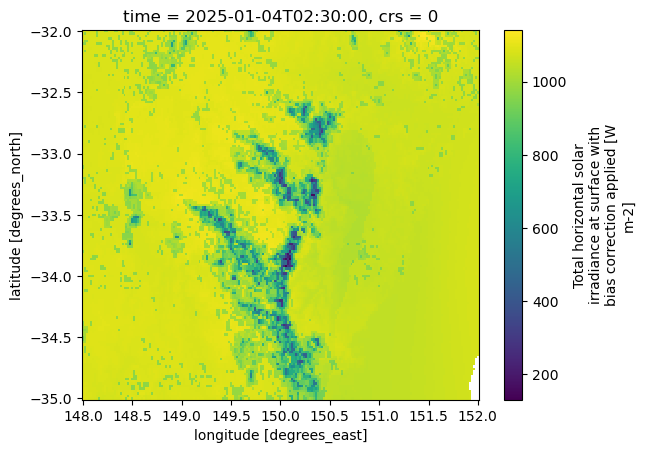

In [36]:
gso.surface_global_irradiance.sel(time='2025-01-04T02:30').plot()